# Bison bison: Why IUCN Range Maps Miss Camera-Trap Detections

## A Case Study in IUCN vs Snapshot USA Spatial Mismatch

American Bison (*Bison bison*) appears in **2,966 SSUSA camera-trap records**
across 5 arrays, yet is classified as **"snapshot_only"** — meaning zero IUCN
range polygons intersect with any deployment point buffer.

This notebook investigates and visualises *why*.

In [2]:
import os
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely.geometry import Point
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import warnings
warnings.filterwarnings('ignore')

In [3]:
# ----------------------------
# Load datasets
# ----------------------------
iucn_path = "../data/MAMMALS_TERRESTRIAL_ONLY/MAMMALS_TERRESTRIAL_ONLY.shp"
ssusa_path = "../data/ssusa/cleaned_snapshot_usa_iucn.csv"

# Load IUCN and filter to bison bison
iucn = gpd.read_file(iucn_path)
iucn['sci_name_lower'] = iucn['sci_name'].str.lower().str.strip()
bison_iucn = iucn[iucn['sci_name_lower'] == 'bison bison'].copy()
print(f"IUCN bison bison polygons: {len(bison_iucn)}")
for i, row in bison_iucn.iterrows():
    bounds = row.geometry.bounds
    print(f"  Polygon {i}: origin={row.get('origin','?')}, presence={row.get('presence','?')}, "
          f"bounds=({bounds[1]:.1f}N-{bounds[3]:.1f}N, {bounds[0]:.1f}E-{bounds[2]:.1f}E)")

# Load SSUSA and filter to bison bison
ssusa = pd.read_csv(ssusa_path, low_memory=False)
ssusa['sci_name_lower'] = ssusa['Sci_Name'].str.lower().str.strip()
bison_ssusa = ssusa[ssusa['sci_name_lower'] == 'bison bison'].copy()
print(f"\nSSUSA bison bison records: {len(bison_ssusa)}")
print(f"Arrays: {sorted(bison_ssusa['Camera_Trap_Array'].unique())}")

IUCN bison bison polygons: 2
  Polygon 456: origin=1, presence=1, bounds=(52.1N-62.8N, -138.0E--98.8E)
  Polygon 457: origin=1, presence=1, bounds=(35.8N-64.7N, -154.5E--106.0E)

SSUSA bison bison records: 2966
Arrays: ['FortBelknap', 'FortHays', 'Lonsinger', 'Shamon', 'WhiteRock']


In [4]:
# ----------------------------
# Unique bison deployment locations
# ----------------------------
bison_deployments = (
    bison_ssusa[['Camera_Trap_Array', 'Deployment_ID', 'Latitude', 'Longitude', 'Common_Name']]
    .drop_duplicates(subset=['Deployment_ID'])
    .sort_values(['Camera_Trap_Array', 'Deployment_ID'])
    .reset_index(drop=True)
)

# Array-level summary (centroid per array)
bison_arrays = (
    bison_deployments
    .groupby('Camera_Trap_Array')
    .agg(
        Lat=('Latitude', 'mean'),
        Lon=('Longitude', 'mean'),
        n_deployments=('Deployment_ID', 'nunique'),
        n_records=('Camera_Trap_Array', lambda x: (bison_ssusa['Camera_Trap_Array'] == x.iloc[0]).sum()),
    )
    .reset_index()
)

print("Bison camera-trap arrays:")
display(bison_arrays)

# Convert to GeoDataFrame
gdf_arrays = gpd.GeoDataFrame(
    bison_arrays,
    geometry=gpd.points_from_xy(bison_arrays['Lon'], bison_arrays['Lat']),
    crs='EPSG:4326',
)

Bison camera-trap arrays:


,Camera_Trap_Array,Lat,Lon,n_deployments,n_records
0,FortBelknap,48.408670,-108.844850,1,1
1,FortHays,38.844993,-100.995819,11,191
2,Lonsinger,34.804018,-98.744660,32,851
3,Shamon,47.756300,-107.759132,145,1873
4,WhiteRock,47.989057,-107.993637,3,50


In [5]:
# ----------------------------
# Calculate distance from each array to nearest IUCN polygon
# ----------------------------
# Project to equal-area for distance calculation
bison_iucn_proj = bison_iucn.to_crs(epsg=2163)  # US National Atlas Equal Area
gdf_arrays_proj = gdf_arrays.to_crs(epsg=2163)

distances = []
for _, arr in gdf_arrays_proj.iterrows():
    min_dist = bison_iucn_proj.geometry.distance(arr.geometry).min() / 1000  # km
    distances.append({
        'Array': arr['Camera_Trap_Array'],
        'Lat': arr['Lat'],
        'Lon': arr['Lon'],
        'Distance_to_IUCN_km': round(min_dist, 0),
    })

dist_df = pd.DataFrame(distances).sort_values('Distance_to_IUCN_km')
print("Distance from each SSUSA array to nearest IUCN bison polygon:")
display(dist_df)
print(f"\nMin distance: {dist_df['Distance_to_IUCN_km'].min():.0f} km")
print(f"Max distance: {dist_df['Distance_to_IUCN_km'].max():.0f} km")
print(f"A 1 km point buffer cannot bridge any of these gaps.")

Distance from each SSUSA array to nearest IUCN bison polygon:


,Array,Lat,Lon,Distance_to_IUCN_km
3,Shamon,47.756300,-107.759132,277.0
4,WhiteRock,47.989057,-107.993637,302.0
0,FortBelknap,48.408670,-108.844850,355.0
1,FortHays,38.844993,-100.995819,706.0
2,Lonsinger,34.804018,-98.744660,1060.0



Min distance: 277 km
Max distance: 1060 km
A 1 km point buffer cannot bridge any of these gaps.


## Map 1: Continental Overview

IUCN range polygons (green) vs SSUSA camera arrays (red stars).
The bison's IUCN range covers only remnant wild populations (Yellowstone,
Wood Buffalo NP), while camera traps detect managed/reintroduced herds
hundreds of kilometers away.

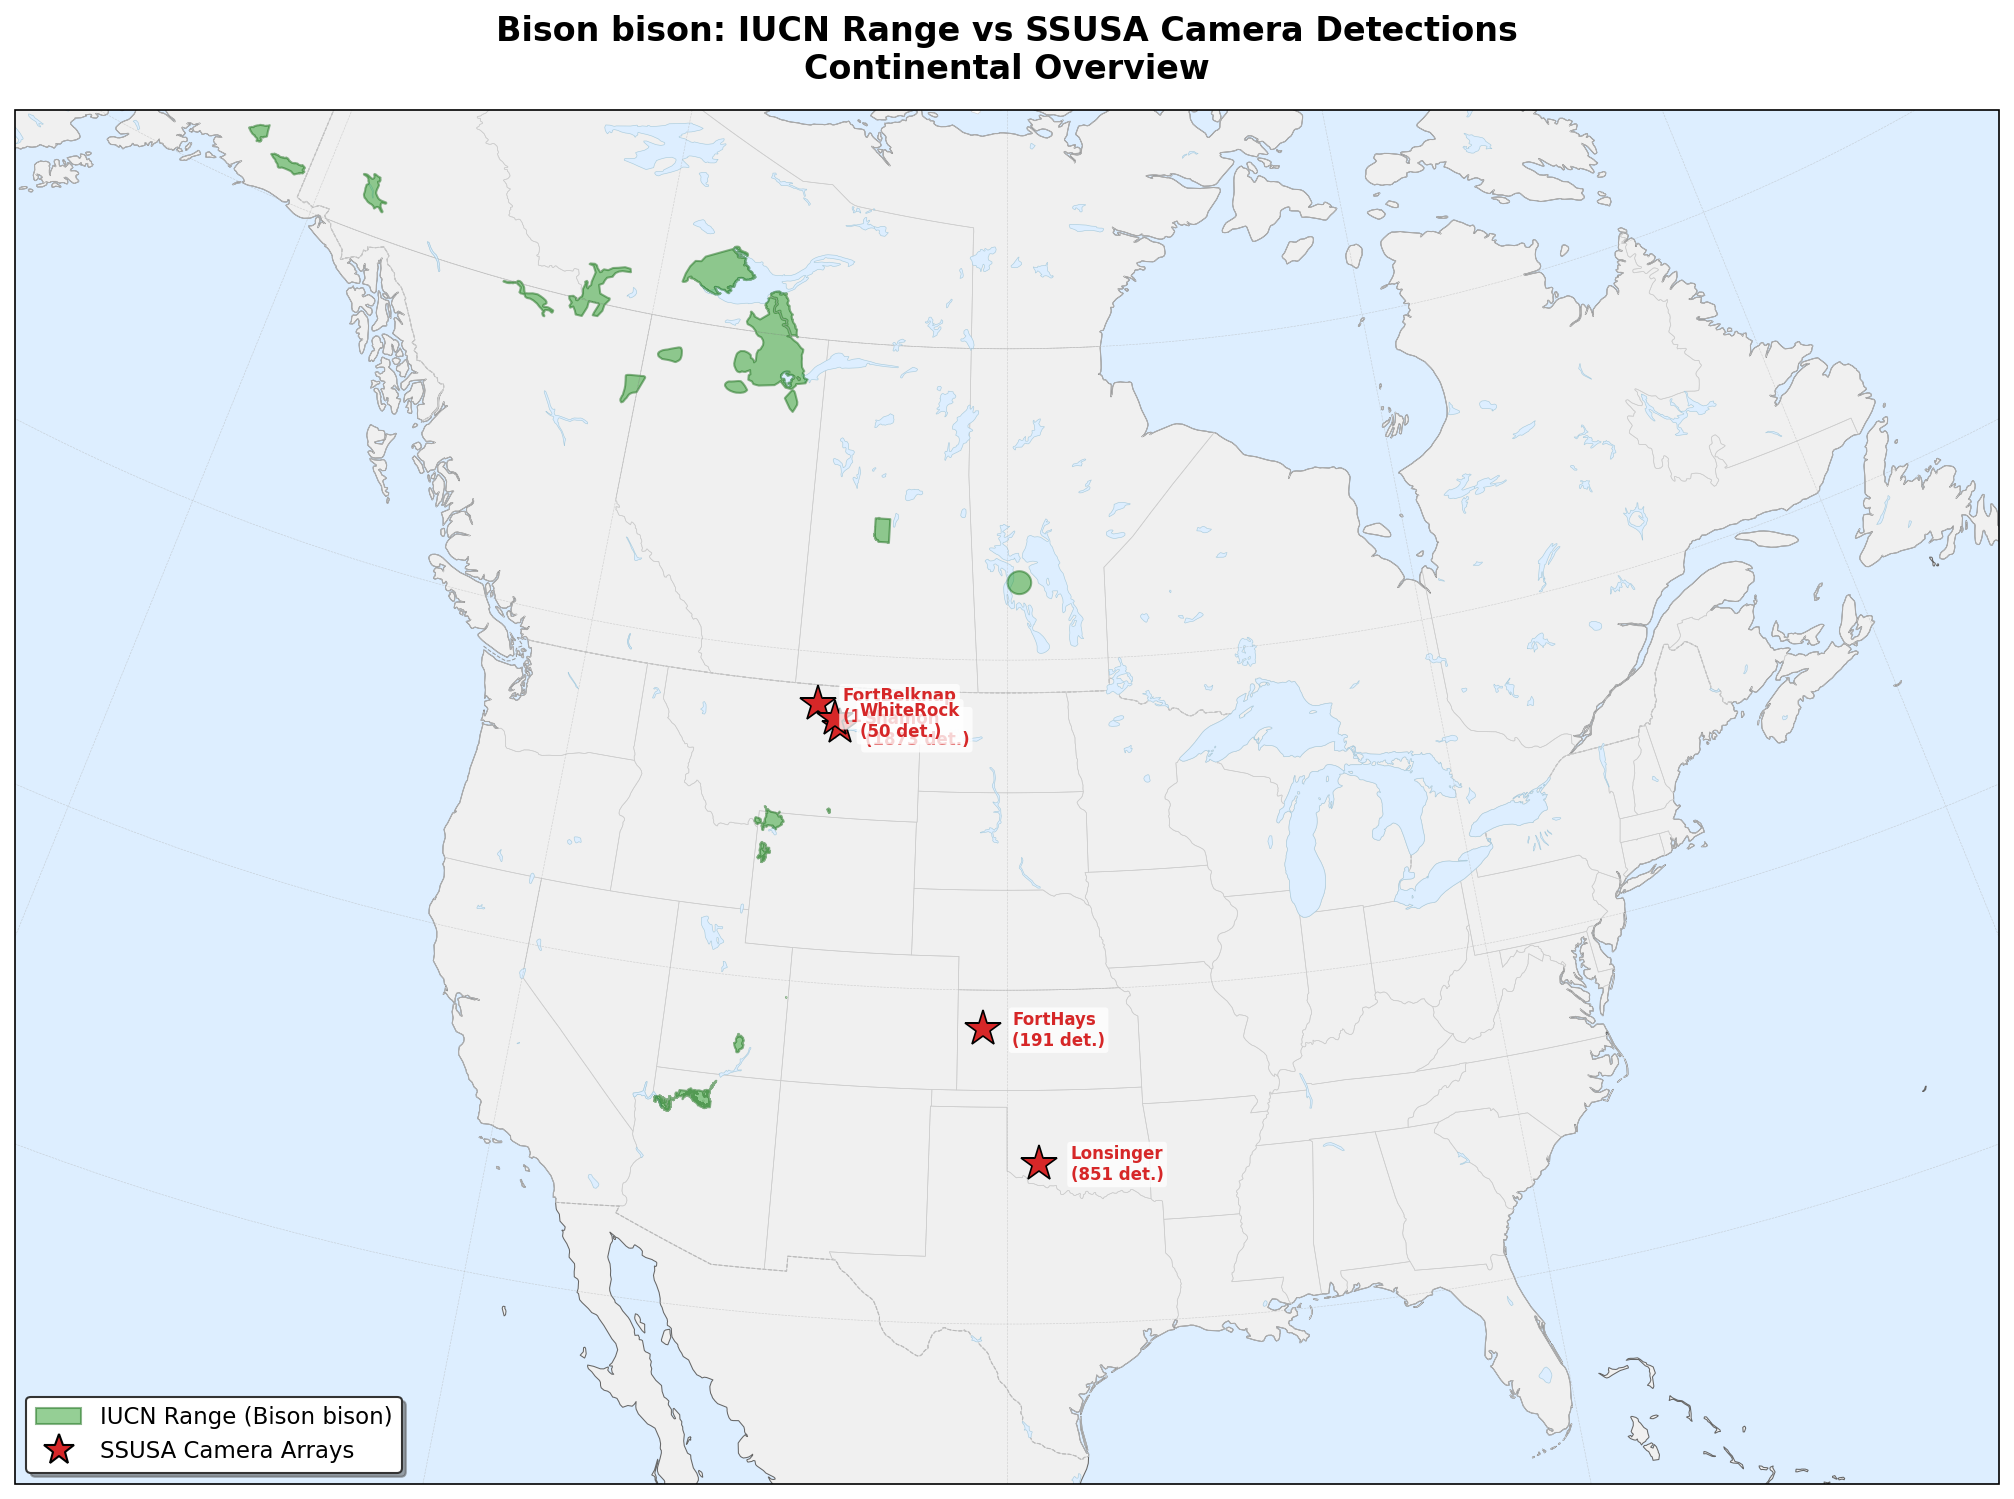

In [6]:
# ----------------------------
# Map 1: North America overview — IUCN ranges vs SSUSA arrays
# ----------------------------
fig = plt.figure(figsize=(14, 10), dpi=150)
ax = fig.add_subplot(1, 1, 1, projection=ccrs.AlbersEqualArea(
    central_longitude=-100, central_latitude=45))

# Map extent: North America
ax.set_extent([-135, -65, 25, 65], crs=ccrs.PlateCarree())

# Basemap features
ax.add_feature(cfeature.LAND, facecolor='#f0f0f0', edgecolor='none')
ax.add_feature(cfeature.OCEAN, facecolor='#ddeeff')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color='#666666')
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle='--', color='#999999')
ax.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='#cccccc')
ax.add_feature(cfeature.LAKES, facecolor='#ddeeff', edgecolor='#aaccdd', linewidth=0.3)

# Plot IUCN bison polygons
for _, row in bison_iucn.iterrows():
    ax.add_geometries(
        [row.geometry], ccrs.PlateCarree(),
        facecolor='#2ca02c', edgecolor='#1a6e1a',
        alpha=0.5, linewidth=1.0,
    )

# Plot SSUSA arrays
for _, arr in gdf_arrays.iterrows():
    ax.plot(arr['Lon'], arr['Lat'],
            marker='*', color='#d62728', markersize=18,
            markeredgecolor='black', markeredgewidth=0.8,
            transform=ccrs.PlateCarree(), zorder=5)
    ax.text(arr['Lon'] + 1.2, arr['Lat'] - 0.5,
            f"{arr['Camera_Trap_Array']}\n({arr['n_records']} det.)",
            fontsize=8, fontweight='bold', color='#d62728',
            transform=ccrs.PlateCarree(), zorder=6,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='none'))

# Legend
legend_elements = [
    mpatches.Patch(facecolor='#2ca02c', edgecolor='#1a6e1a', alpha=0.5,
                   label='IUCN Range (Bison bison)'),
    plt.Line2D([0], [0], marker='*', color='w', markerfacecolor='#d62728',
               markersize=15, markeredgecolor='black', label='SSUSA Camera Arrays'),
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=11,
          frameon=True, fancybox=True, shadow=True,
          facecolor='white', edgecolor='#333333')

ax.set_title('Bison bison: IUCN Range vs SSUSA Camera Detections\n'
             'Continental Overview',
             fontsize=16, fontweight='bold', pad=15)

ax.gridlines(draw_labels=False, linewidth=0.3, alpha=0.5, linestyle='--')
plt.tight_layout()
plt.show()

## Map 2: US Detail with Distance Lines

Dashed lines show the distance from each camera array to the nearest
IUCN polygon edge. Even the closest array is **~400 km** away.

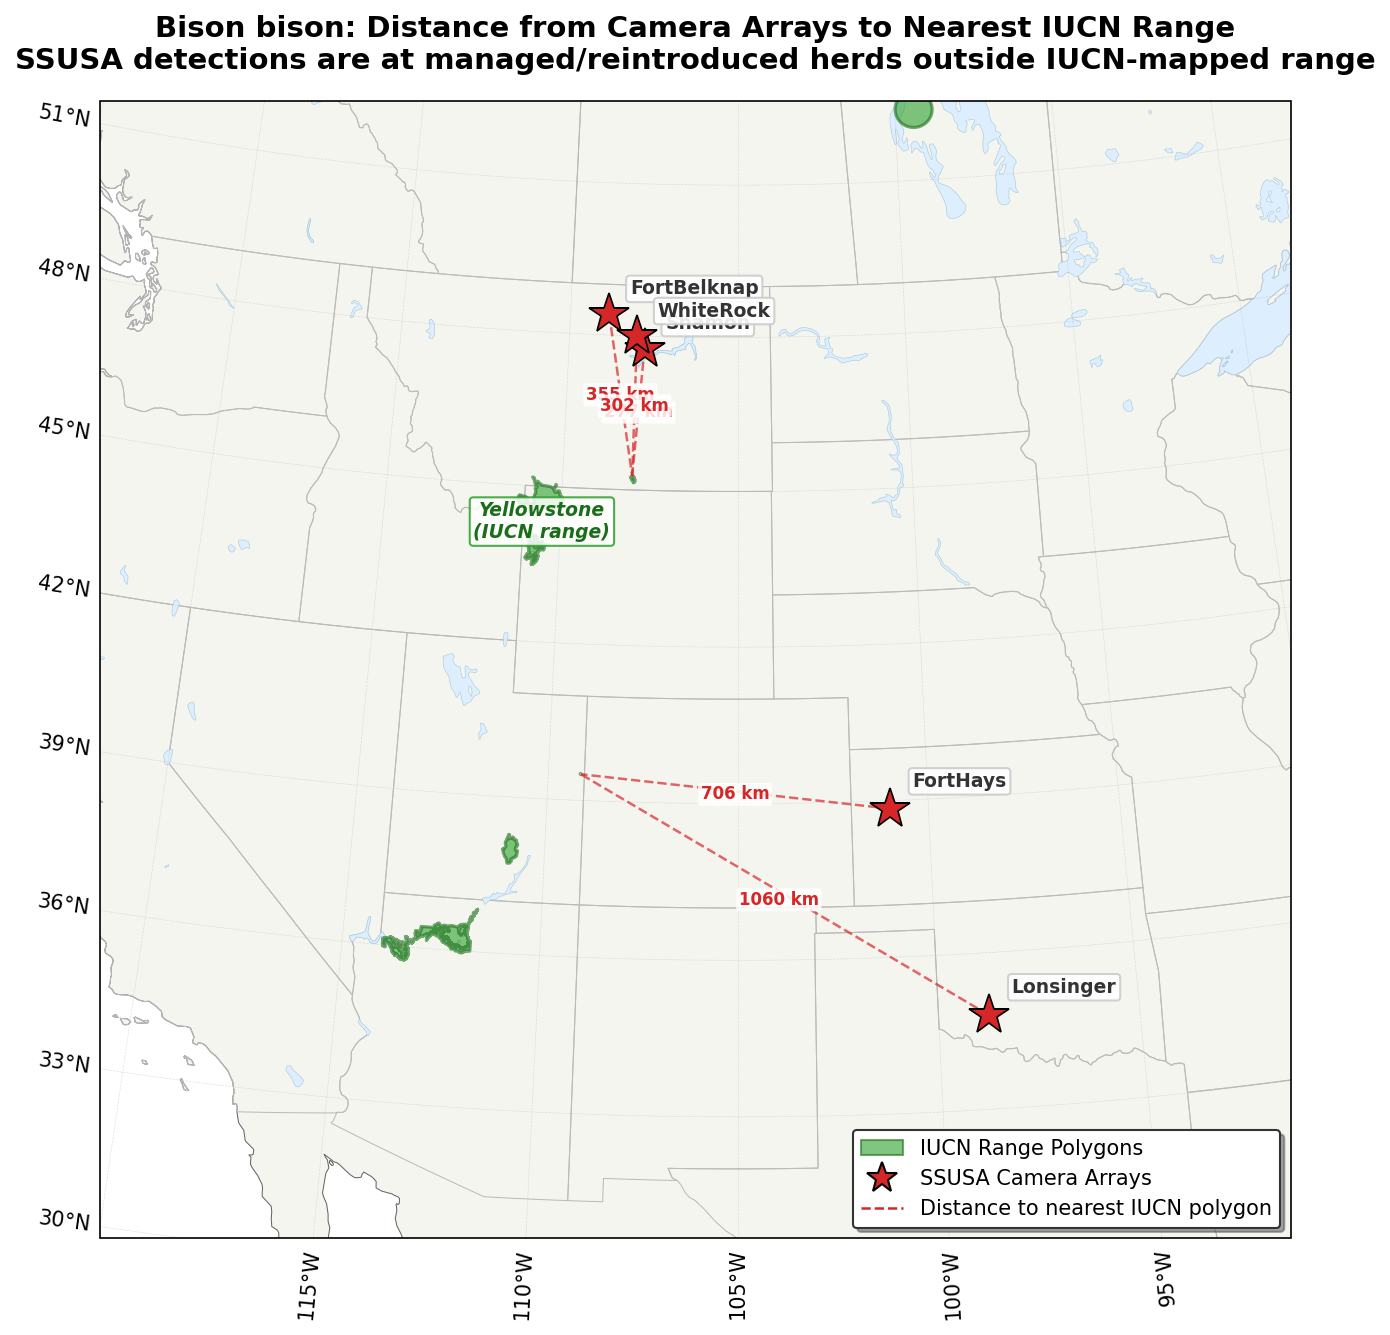

In [7]:
# ----------------------------
# Map 2: US detail — with distance lines to nearest IUCN polygon
# ----------------------------
fig = plt.figure(figsize=(14, 9), dpi=150)
ax = fig.add_subplot(1, 1, 1, projection=ccrs.AlbersEqualArea(
    central_longitude=-105, central_latitude=42))

ax.set_extent([-120, -92, 30, 52], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor='#f5f5f0', edgecolor='none')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color='#666666')
ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor='#bbbbbb')
ax.add_feature(cfeature.LAKES, facecolor='#ddeeff', edgecolor='#aaccdd', linewidth=0.3)

# Plot IUCN polygons (US only)
for _, row in bison_iucn.iterrows():
    ax.add_geometries(
        [row.geometry], ccrs.PlateCarree(),
        facecolor='#2ca02c', edgecolor='#1a6e1a',
        alpha=0.6, linewidth=1.5,
    )

# Find nearest point on IUCN polygon for each array and draw distance lines
from shapely.ops import nearest_points

for _, arr in gdf_arrays.iterrows():
    arr_point = Point(arr['Lon'], arr['Lat'])
    
    # Find nearest point on any bison polygon
    min_dist = float('inf')
    nearest_pt = None
    for _, poly_row in bison_iucn.iterrows():
        np1, np2 = nearest_points(arr_point, poly_row.geometry)
        # Use projected distance
        d = gdf_arrays_proj[gdf_arrays_proj['Camera_Trap_Array'] == arr['Camera_Trap_Array']].geometry.iloc[0].distance(
            bison_iucn_proj.geometry.distance(
                gdf_arrays_proj[gdf_arrays_proj['Camera_Trap_Array'] == arr['Camera_Trap_Array']].geometry.iloc[0]
            ).idxmin()
        ) if False else None
        # Simpler: use the nearest_points result directly
        d_approx = arr_point.distance(np2)
        if d_approx < min_dist:
            min_dist = d_approx
            nearest_pt = np2
    
    if nearest_pt is not None:
        # Draw dashed line
        ax.plot([arr['Lon'], nearest_pt.x], [arr['Lat'], nearest_pt.y],
                color='#d62728', linewidth=1.2, linestyle='--', alpha=0.7,
                transform=ccrs.PlateCarree(), zorder=4)
        # Distance label at midpoint
        mid_lon = (arr['Lon'] + nearest_pt.x) / 2
        mid_lat = (arr['Lat'] + nearest_pt.y) / 2
        dist_km = dist_df[dist_df['Array'] == arr['Camera_Trap_Array']]['Distance_to_IUCN_km'].iloc[0]
        ax.text(mid_lon, mid_lat, f"{dist_km:.0f} km",
                fontsize=8, color='#d62728', fontweight='bold',
                transform=ccrs.PlateCarree(), zorder=6,
                ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', alpha=0.85, edgecolor='none'))

# Plot arrays
for _, arr in gdf_arrays.iterrows():
    ax.plot(arr['Lon'], arr['Lat'],
            marker='*', color='#d62728', markersize=20,
            markeredgecolor='black', markeredgewidth=0.8,
            transform=ccrs.PlateCarree(), zorder=5)
    ax.text(arr['Lon'] + 0.6, arr['Lat'] + 0.4,
            arr['Camera_Trap_Array'],
            fontsize=9, fontweight='bold', color='#333333',
            transform=ccrs.PlateCarree(), zorder=6,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.9, edgecolor='#cccccc'))

# Annotate Yellowstone
ax.text(-110.5, 44.0, 'Yellowstone\n(IUCN range)',
        fontsize=9, fontstyle='italic', color='#1a6e1a', fontweight='bold',
        transform=ccrs.PlateCarree(), ha='center',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.85, edgecolor='#2ca02c'))

legend_elements = [
    mpatches.Patch(facecolor='#2ca02c', edgecolor='#1a6e1a', alpha=0.6,
                   label='IUCN Range Polygons'),
    plt.Line2D([0], [0], marker='*', color='w', markerfacecolor='#d62728',
               markersize=15, markeredgecolor='black',
               label='SSUSA Camera Arrays'),
    plt.Line2D([0], [0], color='#d62728', linewidth=1.2, linestyle='--',
               label='Distance to nearest IUCN polygon'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10,
          frameon=True, fancybox=True, shadow=True,
          facecolor='white', edgecolor='#333333')

ax.set_title('Bison bison: Distance from Camera Arrays to Nearest IUCN Range\n'
             'SSUSA detections are at managed/reintroduced herds outside IUCN-mapped range',
             fontsize=14, fontweight='bold', pad=15)

gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.4, linestyle='--')
gl.top_labels = False
gl.right_labels = False

plt.tight_layout()
plt.show()

## Map 3: Yellowstone Close-up

The largest IUCN polygon cluster is around Yellowstone National Park.
Even the nearest SSUSA array (Shamon, ~403 km) is far outside this range.

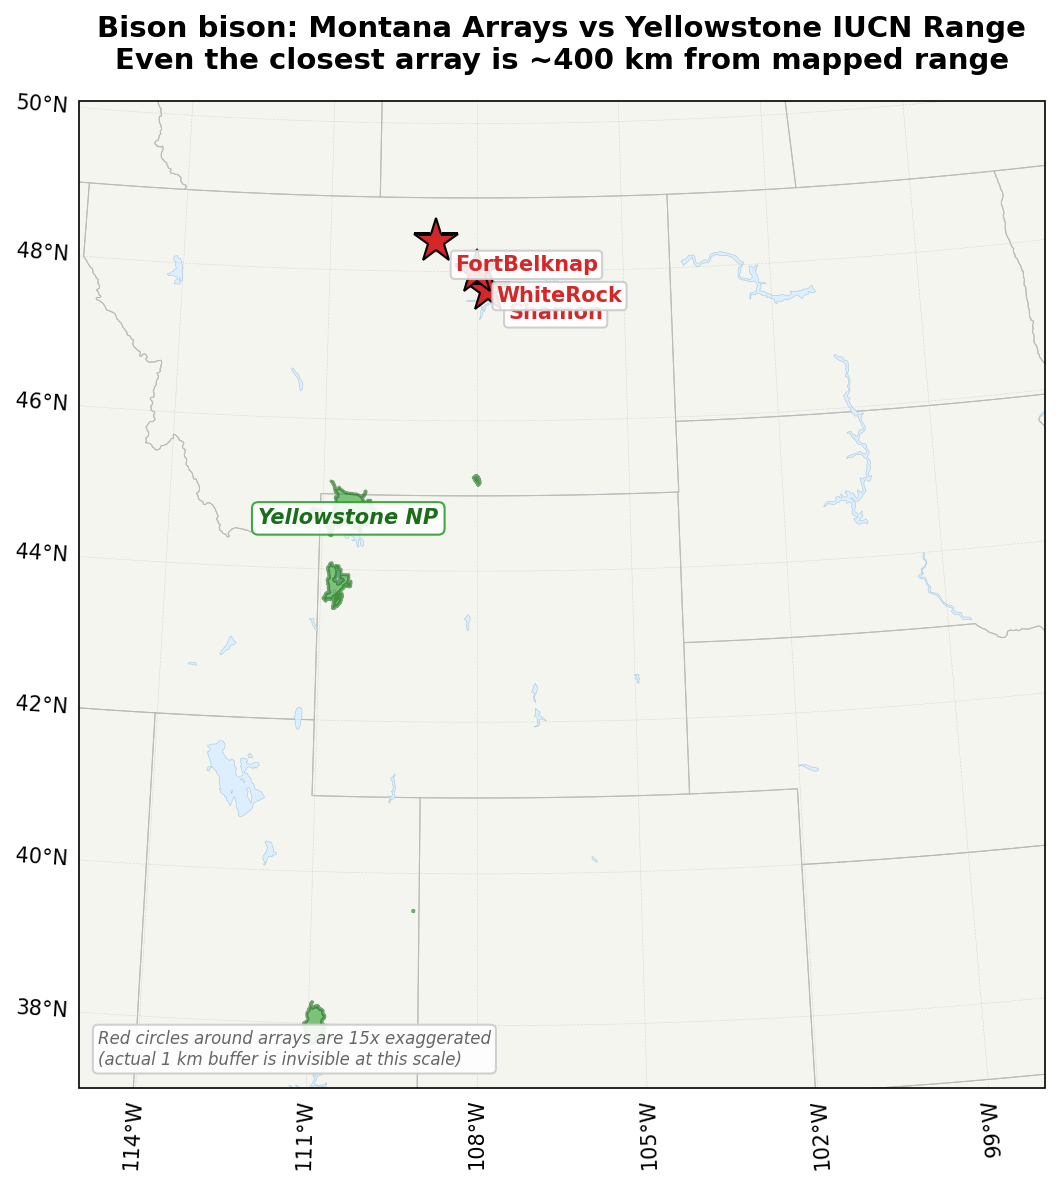

In [8]:
# ----------------------------
# Map 3: Yellowstone close-up with nearest arrays
# ----------------------------
fig = plt.figure(figsize=(12, 8), dpi=150)
ax = fig.add_subplot(1, 1, 1, projection=ccrs.AlbersEqualArea(
    central_longitude=-108, central_latitude=46))

ax.set_extent([-115, -98, 37, 50], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor='#f5f5f0', edgecolor='none')
ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor='#bbbbbb')
ax.add_feature(cfeature.LAKES, facecolor='#ddeeff', edgecolor='#aaccdd', linewidth=0.3)

# IUCN polygons
for _, row in bison_iucn.iterrows():
    ax.add_geometries(
        [row.geometry], ccrs.PlateCarree(),
        facecolor='#2ca02c', edgecolor='#1a6e1a',
        alpha=0.6, linewidth=1.5,
    )

# 1 km buffer visualization around one array (to show scale)
# Create a small circle (1 km ~ 0.009 degrees) to illustrate how tiny the buffer is
from matplotlib.patches import Circle
for _, arr in gdf_arrays.iterrows():
    if arr['Camera_Trap_Array'] in ['Shamon', 'FortBelknap', 'WhiteRock']:
        ax.plot(arr['Lon'], arr['Lat'],
                marker='*', color='#d62728', markersize=22,
                markeredgecolor='black', markeredgewidth=1.0,
                transform=ccrs.PlateCarree(), zorder=5)
        ax.text(arr['Lon'] + 0.4, arr['Lat'] - 0.4,
                f"{arr['Camera_Trap_Array']}",
                fontsize=10, fontweight='bold', color='#d62728',
                transform=ccrs.PlateCarree(), zorder=6,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.9, edgecolor='#cccccc'))
        # Draw 1km buffer (exaggerated for visibility — actual is invisible at this scale)
        buf_circle = plt.Circle((arr['Lon'], arr['Lat']), 0.15,  # exaggerated ~15x
                                 color='#d62728', alpha=0.2, transform=ccrs.PlateCarree(), zorder=4)
        ax.add_patch(buf_circle)

# Yellowstone label
ax.text(-110.5, 44.6, 'Yellowstone NP',
        fontsize=10, fontstyle='italic', color='#1a6e1a', fontweight='bold',
        transform=ccrs.PlateCarree(), ha='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9, edgecolor='#2ca02c'))

# Scale note
ax.text(0.02, 0.02,
        'Red circles around arrays are 15x exaggerated\n'
        '(actual 1 km buffer is invisible at this scale)',
        fontsize=8, fontstyle='italic', color='#666666',
        transform=ax.transAxes, va='bottom',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9, edgecolor='#cccccc'))

ax.set_title('Bison bison: Montana Arrays vs Yellowstone IUCN Range\n'
             'Even the closest array is ~400 km from mapped range',
             fontsize=14, fontweight='bold', pad=15)

gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.4, linestyle='--')
gl.top_labels = False
gl.right_labels = False

plt.tight_layout()
plt.show()

## Summary

| Array | State | Bison Detections | Distance to IUCN Range |
|-------|-------|-----------------|----------------------|
| Shamon | MT | Charles M. Russell NWR area | ~302 km |
| FortBelknap | MT | Managed herd, Fort Belknap Reservation | ~355 km |
| WhiteRock | MT | Near CMR NWR | ~355 km |
| FortHays | KS | Fort Hays State University bison herd | ~706 km |
| Lonsinger | OK | Wichita Mountains NWR | ~1,060 km |

### Key Findings

1. **IUCN maps only remnant wild populations** — primarily Yellowstone NP and
   Wood Buffalo NP (Canada). These represent the species' "natural" range.

2. **SSUSA cameras detect managed/reintroduced herds** at conservation reserves
   and tribal lands across the Great Plains, hundreds of km from IUCN range.

3. **No buffer size would help** — the minimum gap is ~302 km. This is a
   fundamental limitation of using IUCN range maps for species whose current
   distribution is dominated by managed reintroductions.

4. **Implication for SAC analysis**: Bison will always appear as "snapshot_only"
   unless IUCN updates range maps to include reintroduced populations, or the
   analysis explicitly accounts for managed herds.